## RQ4

Vul-RAG performs iterative, knowledge-augmented vulnerability detection. Instead of injecting all retrieved knowledge items into a single detection prompt, the LLM sequentially reasons over each knowledge item (five retries in case of failure) via (i) a prompt for finding vulnerability causes, which checks whether the input code matches the vulnerability cause, and (ii) a prompt for finding fixing solutions, which checks whether the code applies the corresponding fixing solution.
The process terminates once the code is identified as vulnerable or all items have been considered, in which case the code is classified as non-vulnerable. 
 
--max_knowledge, default = 3

--retry_times, default 5

calculate distribution via: ``python calculate_iterations.py qwen2.5-coder-32b-instruct__sum-qwen2.5-coder-32b-instruct``


-> Of the items that were difficult enough to require a 2nd iteration, what percentage were solved at that step?

Saved plot to: iteration_conditional_success.pdf


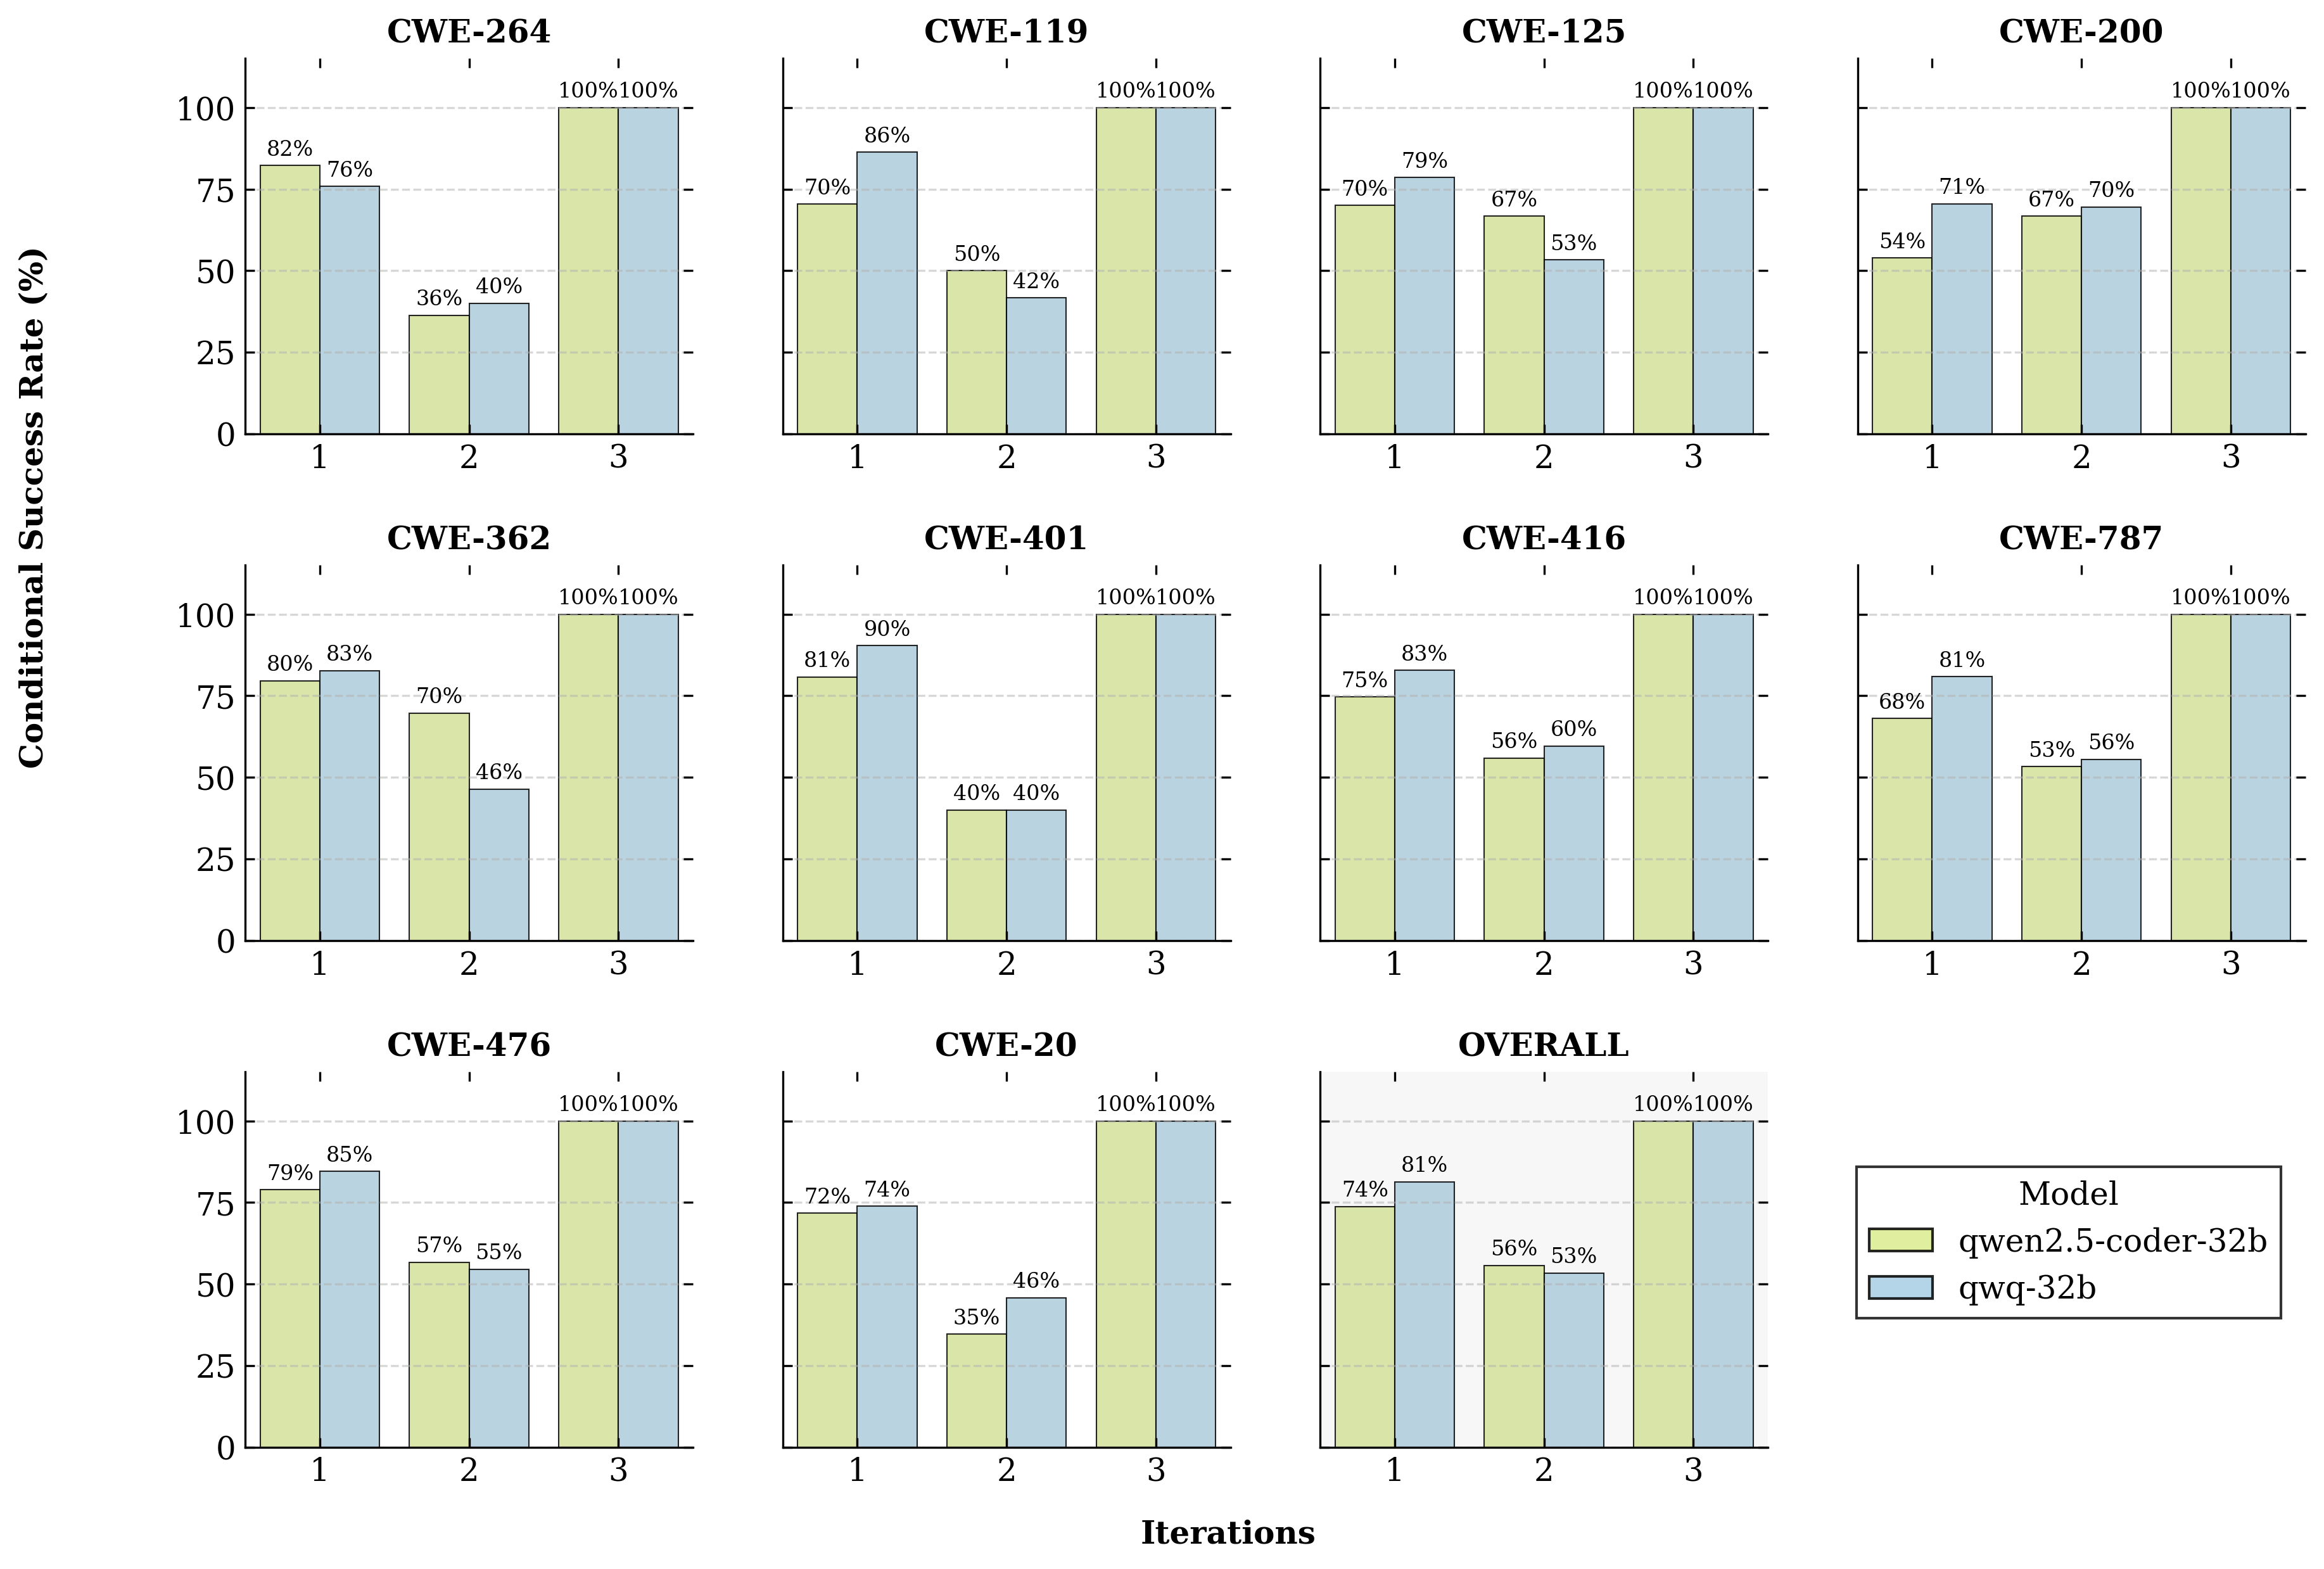

In [ ]:
# Conditional success rates for reasoning vs. baseline model.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set_theme(style="whitegrid")

# --- 1. SET ACADEMIC STYLING ---
params = {
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 12,
    "ytick.color": "black",
    "xtick.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "lines.linewidth": 0.5,
    "figure.dpi": 300,
}
plt.rcParams.update(params)

color_std = "#DBED8E" 
color_rsn = "#a6cee3" 

CWE_ORDER = [
    "CWE-264", "CWE-119", "CWE-125", 
    "CWE-200", "CWE-362", "CWE-401", 
    "CWE-416", "CWE-787", "CWE-476", 
    "CWE-20", "OVERALL"
]

def calculate_conditional_metrics(group):
    """
    Calculates the percentage of items finished at Iteration N 
    relative only to the items that reached that iteration.
    """
    counts = group['Iterations'].value_counts().sort_index()
    total_items = counts.sum()
    
    results = []
    remaining_items = total_items
    
    for iteration in sorted(counts.index):
        if remaining_items > 0:
            # How many finished NOW / How many were left to finish
            percentage = (counts[iteration] / remaining_items) * 100
            results.append({'Iterations': iteration, 'Percentage': percentage})
            # Remove those that finished from the pool for the next iteration
            remaining_items -= counts[iteration]
            
    return pd.DataFrame(results)

def plot_model_comparison(file_std, file_rsn):
    if not os.path.exists(file_std) or not os.path.exists(file_rsn):
        print("Error: Files not found.")
        return

    # 2. Load and Label Data
    df_std = pd.read_csv(file_std)
    df_std['Model'] = 'qwen2.5-coder-32b-instruct'
    
    df_rsn = pd.read_csv(file_rsn)
    df_rsn['Model'] = 'qwq-32b'

    df_raw = pd.concat([df_std, df_rsn], ignore_index=True)
    df_raw = df_raw[df_raw['CWE'] != 'OVERALL']
    
    df_overall = df_raw.copy()
    df_overall['CWE'] = 'OVERALL'
    
    df = pd.concat([df_raw, df_overall], ignore_index=True)
    df['Iterations'] = df['Iterations'].astype(int)

    # 3. Normalize Data (Conditional Percentages)
    # This applies the new logic: Iteration 2 is % of items remaining AFTER Iteration 1
    df_norm = df.groupby(['CWE', 'Model']).apply(calculate_conditional_metrics).reset_index()
    # Remove the extra 'level_2' column created by apply()
    if 'level_2' in df_norm.columns:
        df_norm = df_norm.drop(columns=['level_2'])

    # 4. Create the Grid Plot
    g = sns.catplot(
        data=df_norm, x="Iterations", y="Percentage", hue="Model", 
        col="CWE", col_order=CWE_ORDER, kind="bar",
        palette=[color_std, color_rsn], 
        height=2.8, 
        aspect=1.1, 
        col_wrap=4, 
        sharex=True, sharey=True, alpha=0.85,
        edgecolor="black", linewidth=0.5, legend=False 
    )

    # 5. Styling and Annotations
    g.set_titles("{col_name}", size=12, weight='bold')
    # Updated Label to reflect conditional nature
    g.set_axis_labels("", "") 
    g.set(ylim=(0, 115))

    for ax in g.axes.flat:
        ax.tick_params(labelbottom=True, direction="in", top=True, right=True)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        
        if ax.get_title() == "OVERALL":
            ax.set_facecolor('#f7f7f7')

        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f"{height:.0f}%", (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center', fontsize=8, xytext=(0, 6), textcoords='offset points')

    # --- 6. LEGEND POSITIONING ---
    legend_labels = ['qwen2.5-coder-32b', 'qwq-32b']
    handles = [plt.Rectangle((0,0),1,1, color=color_std, ec="k", alpha=0.85),
               plt.Rectangle((0,0),1,1, color=color_rsn, ec="k", alpha=0.85)]
    
    pos_overall = g.axes[10].get_position()
    col_width = pos_overall.width
    x_center = pos_overall.x1 + (col_width / 2)
    y_center = pos_overall.y0 + (pos_overall.height / 2)

    g.fig.legend(handles, legend_labels, 
                 loc='center', 
                 bbox_to_anchor=(x_center, y_center), 
                 title="Model",
                 frameon=True, 
                 fontsize=12)

    # 7. Final Labels and Layout
    g.fig.text(0.5, 0.01, 'Iterations', ha='center', fontsize=12, fontweight='bold')
    # Updated Y-axis label to be more descriptive of the new logic
    g.fig.text(-0.01, 0.5, 'Conditional Success Rate (%)', ha='center', rotation='vertical', fontsize=12, fontweight='bold')

    plt.subplots_adjust(top=0.94, bottom=0.07, left=0.08, right=0.96, hspace=0.35, wspace=0.2)
    
    output_file = "iteration_conditional_success.pdf"
    plt.savefig(output_file, bbox_inches='tight')
    print(f"Saved plot to: {output_file}")
    plt.show()

# File paths (Ensure these match your actual generated CSV filenames)
file1 = 'iteration_dist_qwen2.5-coder-32b-instruct__sum-qwen2.5-coder-32b-instruct.csv'
file2 = 'iteration_dist_qwq-32b__sum-qwq-32b.csv'

if __name__ == "__main__":
    plot_model_comparison(file1, file2)

In [ ]:
# Comparison of output lengths in tokens between baseline and reasoning models

import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import importlib.util
from transformers import AutoTokenizer

# CONFIGURATION
params = {
    "ytick.color": "black",
    "xtick.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "text.usetex": False, # Set to True if you have a full LaTeX env
    "font.family": "serif",
    "legend.edgecolor": "black",
    "legend.fancybox": False,
    "lines.linewidth": 0.5,
    "figure.figsize": (5, 3), 
    "hatch.linewidth": 0.5,
    "font.size": 7,
    "patch.edgecolor": "black",
    "figure.dpi": 300,
}
plt.rcParams.update(params)

color1 = "#DBED8E" 
color2 = "#a6cee3" # Light Blue

palette = {
    # Non-reasoning
    "qwen2.5-coder-32b": "#DBED8E",  
    # Reasoning (QwQ)
    "qwq-32b": "#a6cee3", 
    # Reasoning (DeepSeek R1 scaling)
    "deepseek-r1-8b": "#7BA2B6",   # 
    "deepseek-r1-14b": "#61889C",  # 
    "deepseek-r1-32b": "#51788B",  # 
}
markersize = 3

# DATA LOADING
def load_model_dict():
    file_path = "vul-rag/utils/llm_client.py"
    if not os.path.exists(file_path):
        file_path = "/beegfs/scratch/workspace/es_sakaniew-rag_benchmark/vul-rag/utils/llm_client.py"
    spec = importlib.util.spec_from_file_location("llm_client", file_path)
    llm_client = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(llm_client)
    return getattr(llm_client, "_MODEL_DICT_LLM", {})

def collect_raw_token_counts():
    MODEL_DICT = load_model_dict()
    MODELS_TO_COMPARE = [
        ("qwen2.5-coder-32b", "qwen2.5-coder-32b-instruct__sum-qwen2.5-coder-32b-instruct", "qwen2.5-coder-32b-instruct"),
        ("qwq-32b", "qwq-32b__sum-qwq-32b", "qwq-32b"),
        ("deepseek-r1-8b", "deepseek-r1-8b__sum-deepseek-r1-8b", "deepseek-r1-8b"),
        ("deepseek-r1-14b", "deepseek-r1-14b__sum-deepseek-r1-14b", "deepseek-r1-14b"),
        ("deepseek-r1-32b", "deepseek-r1-32b__sum-deepseek-r1-32b", "deepseek-r1-32b")
    ]
    DATASETS = [f"linux_kernel_CWE-{i}" for i in [20, 119, 125, 200, 264, 362, 401, 416, 476, 787]]
    
    all_records = []
    for display_name, folder_name, llm_key in MODELS_TO_COMPARE:
        if llm_key not in MODEL_DICT: continue
        hf_path = MODEL_DICT[llm_key][0]
        print(f"Tokenizing {display_name}...")
        tokenizer = AutoTokenizer.from_pretrained(hf_path, trust_remote_code=True, use_fast=True)
        model_dir = os.path.join("output", folder_name)
        
        for dataset in DATASETS:
            file_path = os.path.join(model_dir, f"{dataset}_result_{folder_name}.json")
            if not os.path.exists(file_path): continue
            with open(file_path, 'r') as f:
                data = json.load(f)
            for item in data:
                for state in ["detect_result_before", "detect_result_after"]:
                    if state in item:
                        for it in item[state].get("detect_result", []):
                            text = it.get("vul_output", "")
                            if text:
                                tokens = len(tokenizer.encode(text, add_special_tokens=False))
                                all_records.append({"Model": display_name, "Tokens": tokens})
    return pd.DataFrame(all_records)

def compute_statistics(df):
    stats = df.groupby("Model")["Tokens"].agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        q1=lambda x: np.percentile(x, 25),
        q3=lambda x: np.percentile(x, 75),
    )

    stats["IQR"] = stats["q3"] - stats["q1"]

    # formatting
    stats = stats.sort_index()
    print("\n=== Token Statistics per Model ===")
    print(stats.round(2))

    return stats

def create_academic_violinplot(df):
    fig, ax = plt.subplots(layout="constrained")
    
    # Violin plot shows the density "shape" of the data
    sns.violinplot(
        data=df, x="Model", y="Tokens", ax=ax,
        palette=palette, 
        split=False,
        inner="quart",      # Shows the 25th, 50th, and 75th percentiles
        linewidth=1.,
        cut=0,               # Limits the violin to the actual data range
        saturation=1
    )

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    ax.yaxis.set_minor_locator(AutoMinorLocator(n=2))
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax.grid(which="both", axis="y", linestyle='--', alpha=0.3)
    ax.set_ylabel("Tokens", fontsize=9)
    ax.set_xlabel("Model", fontsize=9)

    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.5)  # after first model

    plt.savefig("token_violin_academic.pdf")
    print("Violin plot saved.")

In [56]:
raw_df = collect_raw_token_counts()
stats_df = compute_statistics(raw_df)

Tokenizing qwen2.5-coder-32b...
Tokenizing qwq-32b...
Tokenizing deepseek-r1-8b...
Tokenizing deepseek-r1-14b...
Tokenizing deepseek-r1-32b...

=== Token Statistics per Model ===
                      mean  median     std  min   max      q1       q3     IQR
Model                                                                         
deepseek-r1-14b     928.91   738.0  593.07  264  4086  560.00  1053.00   493.0
deepseek-r1-32b     876.31   688.0  534.40  261  3977  550.75  1007.25   456.5
deepseek-r1-8b      954.99   688.5  708.14  308  4327  550.00  1024.50   474.5
qwen2.5-coder-32b   569.89   540.0  162.40  292  2039  468.00   634.00   166.0
qwq-32b            1594.56  1385.0  783.87  459  4093  989.00  2024.00  1035.0


/tmp/ipykernel_2256146/450262288.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Violin plot saved.


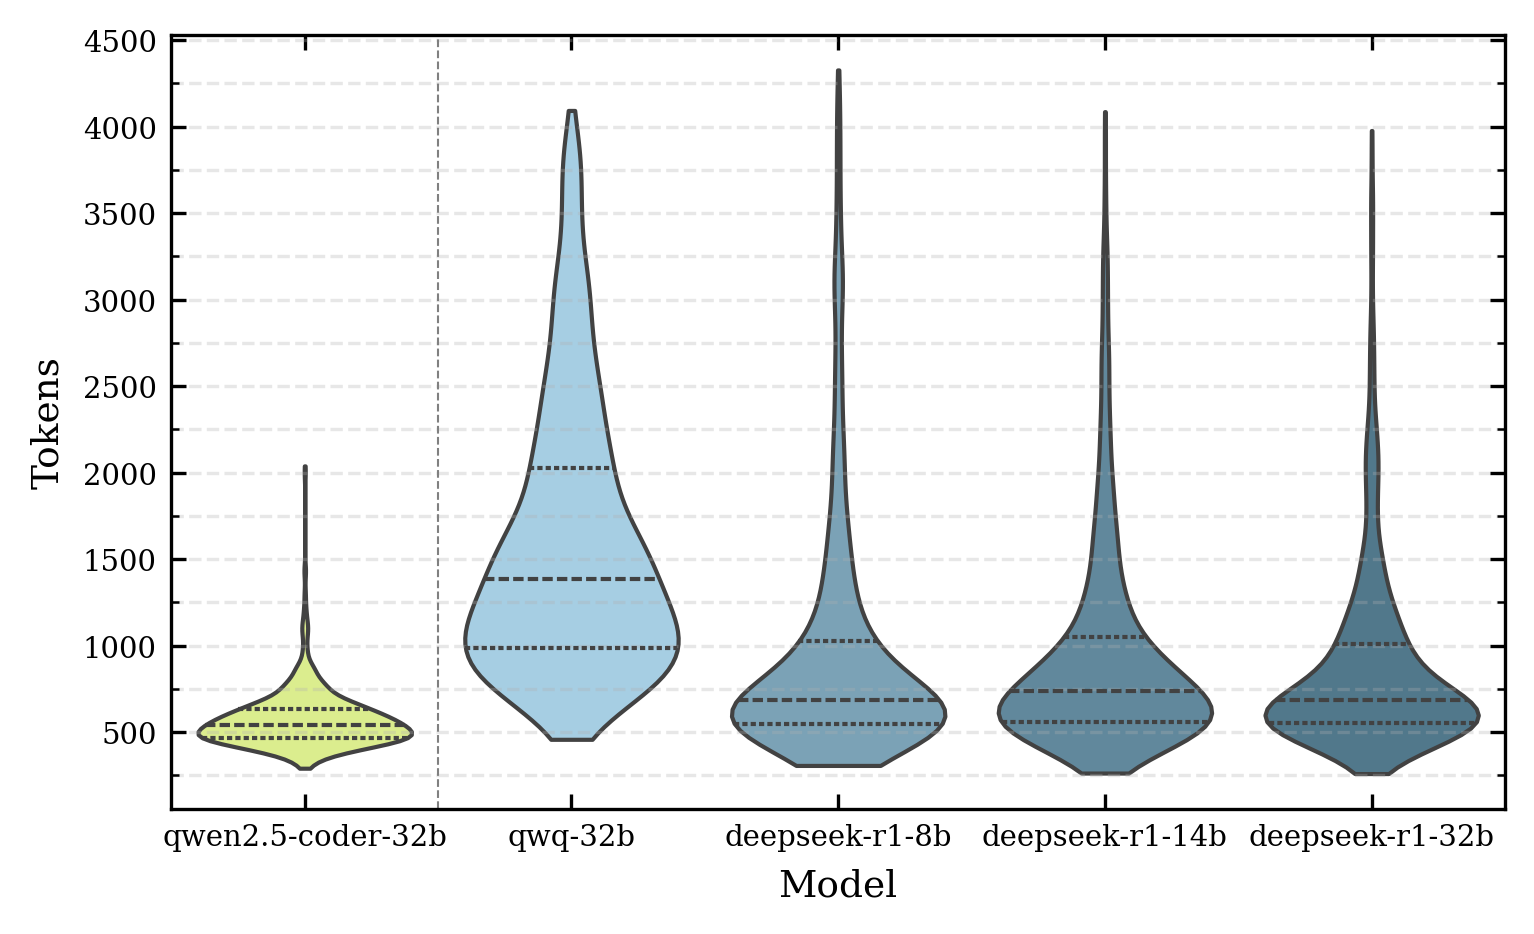

In [54]:
create_academic_violinplot(raw_df)

## RQ1

`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


Loading tokenizer for deepseek-coder-v2-instruct...
Combined plot saved as combined_cwe_token_analysis.pdf


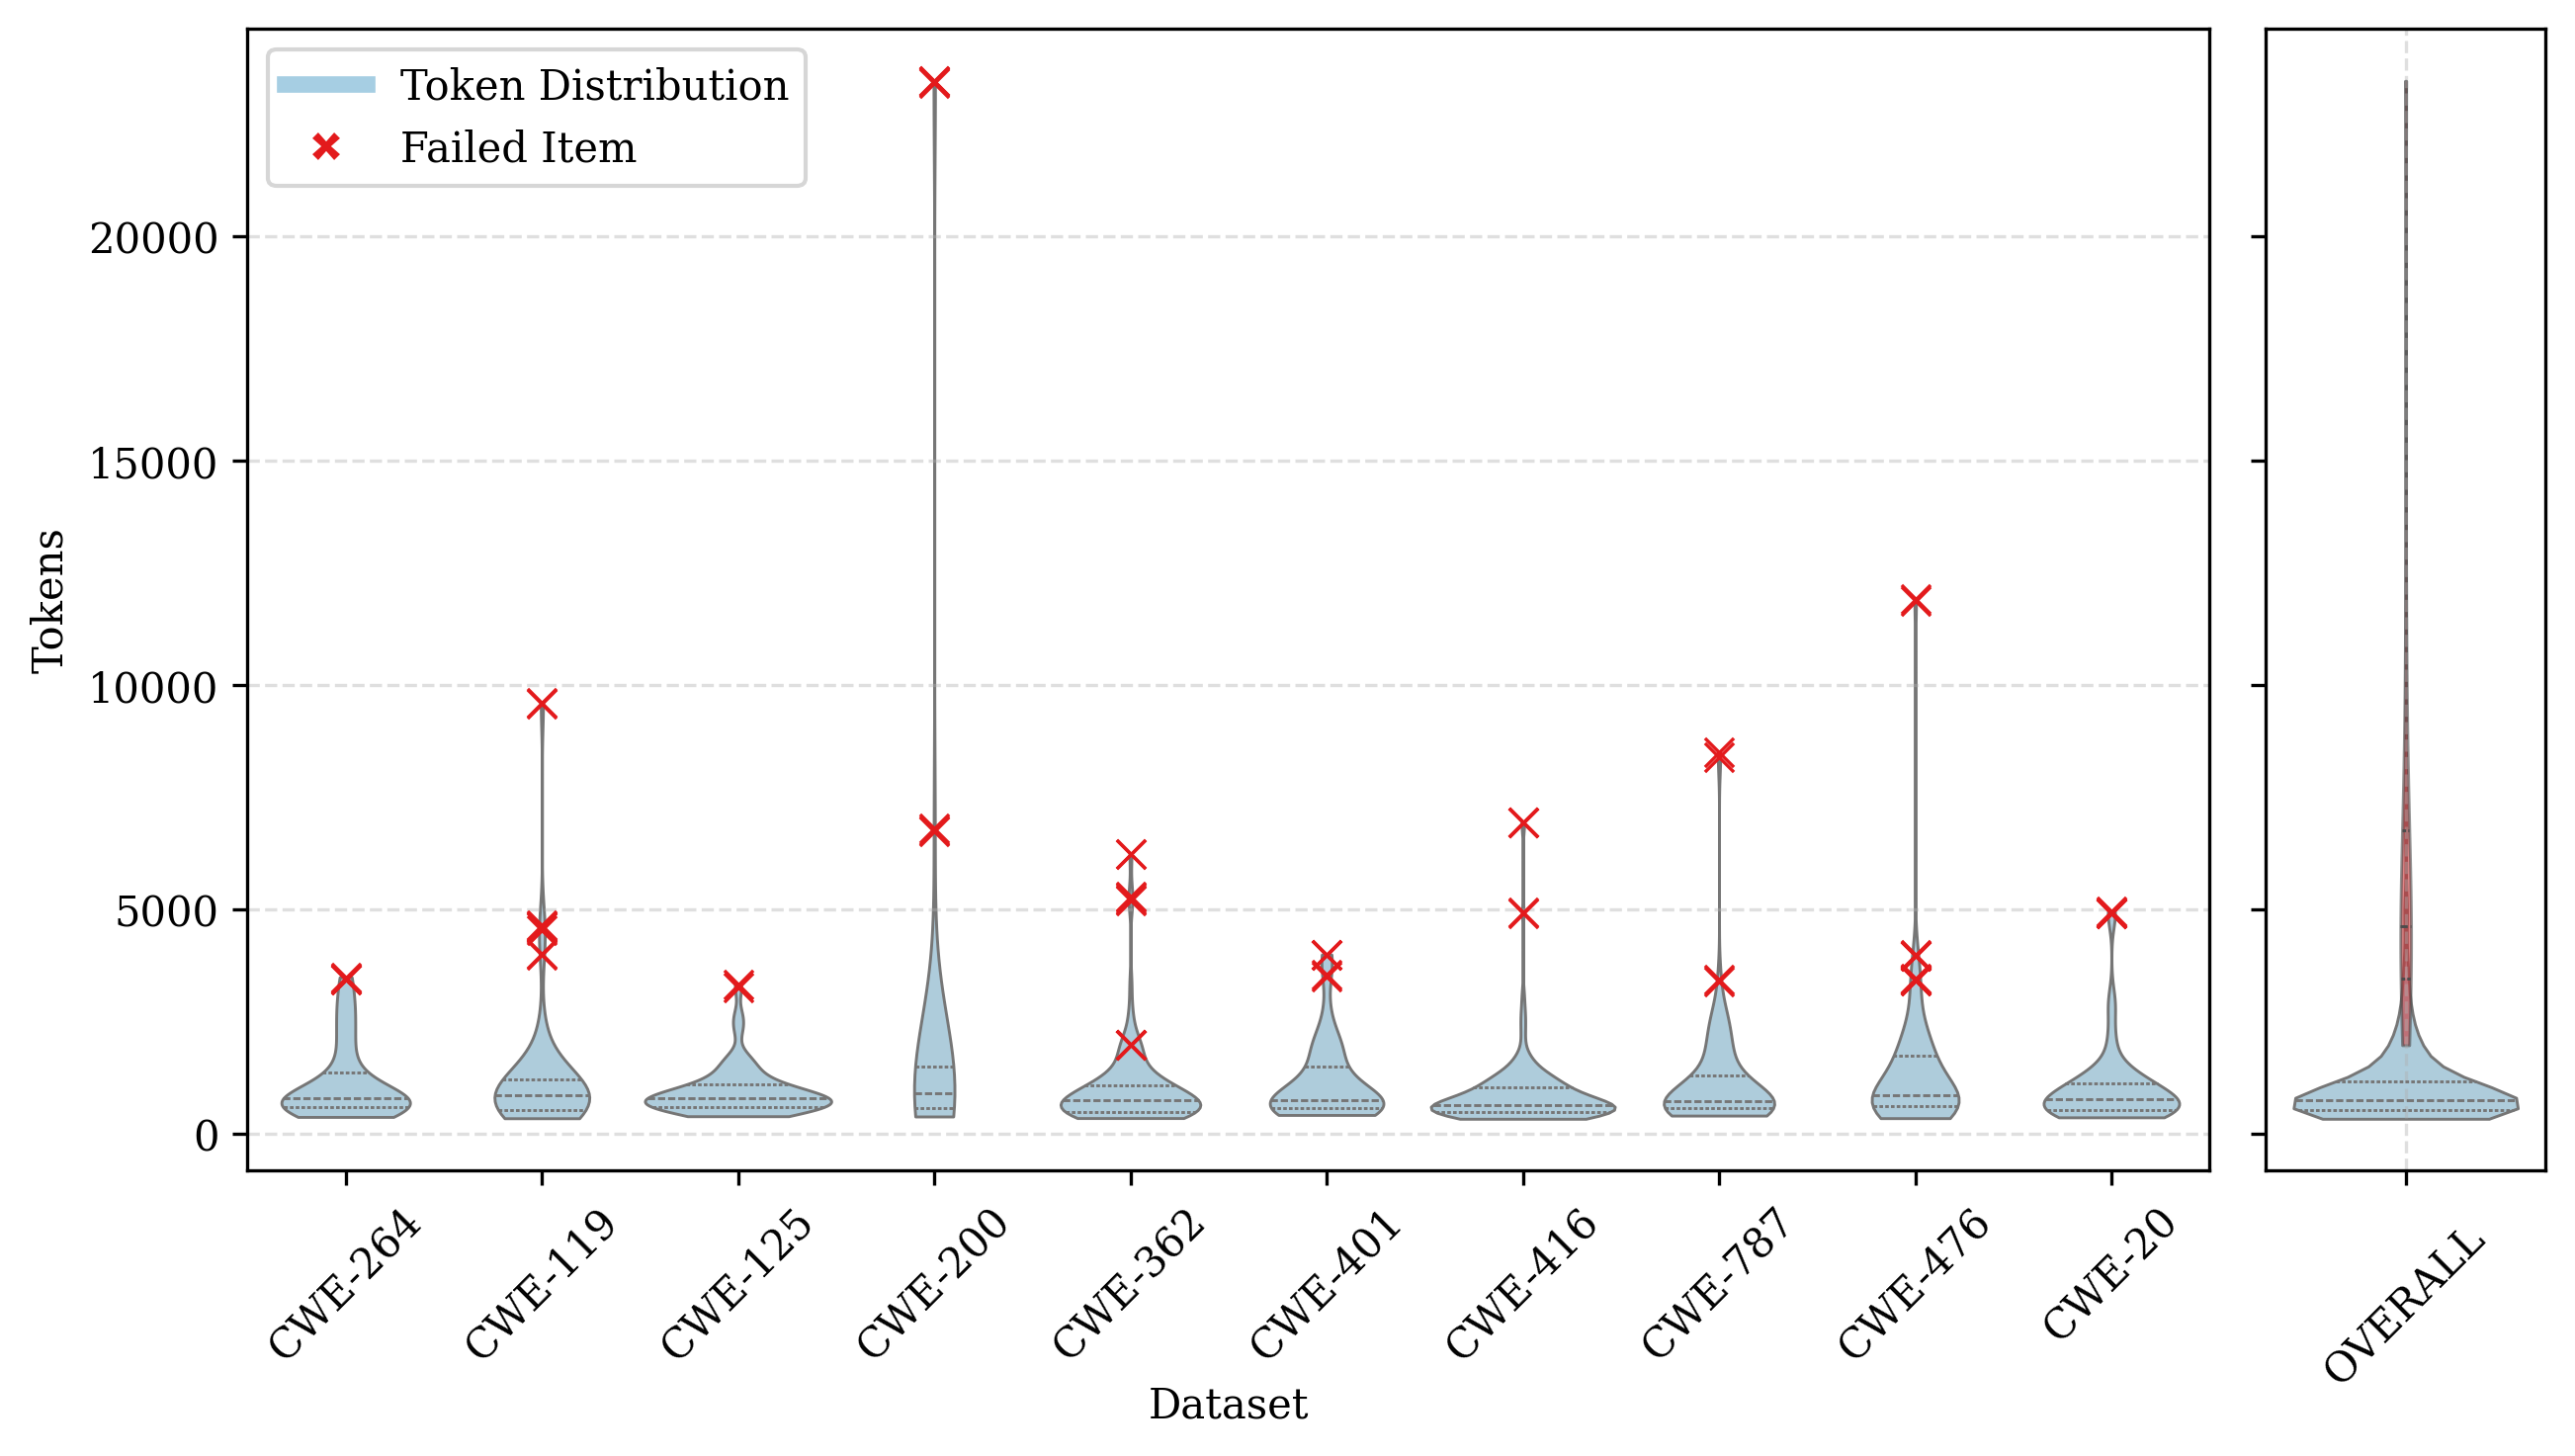

In [ ]:
# Distribution of tokens for the detection prompts across the PairVul CWE subsets
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import importlib.util
from transformers import AutoTokenizer, AutoConfig
import tqdm as notebook_tqdm

params = {
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 10,
    "ytick.color": "black",
    "xtick.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "lines.linewidth": 0.8,
    "figure.figsize": (9, 5),
    "figure.dpi": 300,
}
plt.rcParams.update(params)

MAIN_COLOR = "#a6cee3"  # Light blue for successful
FAIL_COLOR = "#e31a1c"  # Red for failed

FAIL_CASES = {
    "CWE-20": [347],
    "CWE-119": [1137, 1263, 324, 302],
    "CWE-125": [2290],
    "CWE-200": [1437, 326],
    "CWE-264": [1008],
    "CWE-362": [2830, 2767, 2341],
    "CWE-401": [2148, 2100],
    "CWE-416": [2247, 3968],
    "CWE-476": [3447, 1683, 2046],
    "CWE-787": [2524, 2291],
}
CUSTOM_CWE_ORDER = ["CWE-264", "CWE-119", "CWE-125", "CWE-200", "CWE-362", "CWE-401", "CWE-416", "CWE-787", "CWE-476", "CWE-20"]

# DATA LOADING
def load_model_dict():
    file_path = "vul-rag/utils/llm_client.py"
    if not os.path.exists(file_path):
        file_path = "/beegfs/scratch/workspace/es_sakaniew-rag_benchmark/vul-rag/utils/llm_client.py"
    spec = importlib.util.spec_from_file_location("llm_client", file_path)
    llm_client = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(llm_client)
    return getattr(llm_client, "_MODEL_DICT_LLM", {})

def collect_data(folder_name, llm_key):
    MODEL_DICT = load_model_dict()
    DATASETS = [f"linux_kernel_{cwe}" for cwe in CUSTOM_CWE_ORDER]

    if llm_key not in MODEL_DICT:
        print(f"Error: {llm_key} not found.")
        return pd.DataFrame()

    hf_path, model_max_length = MODEL_DICT[llm_key] 
    print(f"Loading tokenizer for {llm_key}...")
    tokenizer = AutoTokenizer.from_pretrained(hf_path, trust_remote_code=False, use_fast=True)
    tokenizer.model_max_length = model_max_length

    all_records = []
    model_dir = os.path.join("output", folder_name)
    
    for dataset in DATASETS:
        file_path = os.path.join(model_dir, f"{dataset}_result_{folder_name}.json")
        if not os.path.exists(file_path):
            print(f"Skipping missing: {file_path}")
            continue
        
        cwe_label = dataset.split('_')[-1] # This extracts "CWE-XXX"
        with open(file_path, 'r') as f:
            data = json.load(f)
            
        for item in data:
            sample_id = item.get("id") or item.get("idx")
            is_failed = sample_id in FAIL_CASES.get(cwe_label, [])
            
            for state in ["detect_result_before", "detect_result_after"]:
                if state in item:
                    for it in item[state].get("detect_result", []):
                        text = it.get("vul_detect_prompt", "")
                        if text:
                            tokens = len(tokenizer.encode(text, add_special_tokens=False))
                            all_records.append({
                                "CWE": cwe_label, 
                                "Tokens": tokens, 
                                "Failed": is_failed,
                                "ID": sample_id
                            })
                            
    df = pd.DataFrame(all_records)
    
    if df.empty:
        return df

    # Ensure the 'CWE' column matches the categories in CUSTOM_CWE_ORDER exactly
    df['CWE'] = pd.Categorical(df['CWE'], categories=CUSTOM_CWE_ORDER, ordered=True)
    return df.sort_values('CWE')


def plot_combined_analysis(df):
    fig = plt.figure(figsize=(10, 5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[7, 1], wspace=0.05)
    
    ax_main = plt.subplot(gs[0])
    ax_hist = plt.subplot(gs[1], sharey=ax_main)

    # --- MAIN VIOLIN PLOT (LEFT) ---
    sns.violinplot(
        data=df, x="CWE", y="Tokens", ax=ax_main,
        color=MAIN_COLOR, inner="quart", linewidth=0.7, cut=0,
        order=CUSTOM_CWE_ORDER, width=0.95
    )

    # Overlay FAILED cases as red markers
    failed_df = df[df['Failed'] == True]
    if not failed_df.empty:
        sns.stripplot(
            data=failed_df, x="CWE", y="Tokens", ax=ax_main,
            color=FAIL_COLOR, 
            marker="x",          
            size=7,              
            jitter=False, 
            linewidth=0.8,       
            order=CUSTOM_CWE_ORDER
        )

    ax_main.set_xticks(range(len(CUSTOM_CWE_ORDER)))
    ax_main.set_xticklabels(CUSTOM_CWE_ORDER, rotation=45)
    
    ax_main.set_ylabel("Tokens")
    ax_main.set_xlabel("Dataset")
    ax_main.grid(axis='y', linestyle='--', alpha=0.4)
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=MAIN_COLOR, lw=4, label='Token Distribution'),
        Line2D([0], [0], marker='X', color='w', label='Failed Item',
               markerfacecolor=FAIL_COLOR, markersize=8)
    ]
    ax_main.legend(handles=legend_elements, loc='upper left', frameon=True)

    # --- (RIGHT) ---
    sns.violinplot(
        data=df,
        y="Tokens",
        ax=ax_hist,
        color=MAIN_COLOR,
        inner="quart",
        linewidth=0.7,
        cut=0
    )

    sns.violinplot(
        data=df[df["Failed"] == True],
        y="Tokens",
        ax=ax_hist,
        color=FAIL_COLOR,
        inner="quart",
        linewidth=0.7,
        cut=0,
        alpha=0.6,
        width=(len(df[df["Failed"]]) / len(df))
    )

    ax_hist.set_xlabel("OVERALL", rotation=45)
    ax_hist.set_ylabel("")
    ax_hist.tick_params(labelleft=False)
    ax_hist.grid(axis='x', linestyle='--', alpha=0.4)

    output_fn = "combined_cwe_token_analysis.pdf"
    plt.savefig(output_fn, bbox_inches='tight')
    print(f"Combined plot saved as {output_fn}")
    plt.show()




if __name__ == "__main__":
    TARGET_FOLDER = "deepseek-r1-32b__sum-deepseek-r1-32b"
    TARGET_KEY = "deepseek-coder-v2-instruct" 

    try:
        df_final = collect_data(TARGET_FOLDER, TARGET_KEY)
        if not df_final.empty:
            plot_combined_analysis(df_final)
        else:
            print("No data found to plot. Check folder paths and CWE strings.")
    except Exception as e:
        import traceback
        traceback.print_exc()